In [1]:

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ours_mamba import MambaULight
import ml_collections
import os
import numpy as np
import tifffile
from utils import visualize_logits
from torch.utils.data import Dataset, DataLoader

/localscratch/conda/envs/mamba_biomed/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/localscratch/conda/envs/mamba_biomed/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


⚠️  Warning: mamba_ssm not installed. MambaULight model will not be available.
   Decoders and utility classes can still be used with ViT.


In [6]:
def random_crop(image_tensor, target_size):
    _, d, h, w = image_tensor.shape
    td, th, tw = target_size

    # 随机裁剪
    start_d = torch.randint(0, d - td + 1, (1,)).item()
    start_h = torch.randint(0, h - th + 1, (1,)).item()
    start_w = torch.randint(0, w - tw + 1, (1,)).item()

    cropped = image_tensor[:, start_d:start_d+td, start_h:start_h+th, start_w:start_w+tw]

    return cropped

class HIPSCDataset(Dataset):
    def __init__(self, root_dir, img_size):
        self.root_dir = root_dir
        self.img_size = img_size  # (D, H, W)
        self.samples = self._create_sample_list()

    def _create_sample_list(self):
        return [f for f in os.listdir(self.root_dir) if f.endswith('.tiff') and 'c4' not in f]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample_path = os.path.join(self.root_dir, self.samples[idx])
        
        # 读取预处理后的图像
        raw_image = tifffile.imread(sample_path)
        
        # 转换为 PyTorch tensor 并添加通道维度
        image_tensor = torch.from_numpy(raw_image).float().unsqueeze(0)
        
        # 执行上采样
        image_tensor = self.upsample(image_tensor)
        
        # 执行随机裁剪
        image_tensor = random_crop(image_tensor, self.img_size)
        
        return image_tensor

    def upsample(self, image_tensor):
        d, h, w = image_tensor.shape[1:]  # 注意：现在shape是(C, D, H, W)
        td, th, tw = self.img_size

        # 计算缩放因子
        d_factor = max(1, td / d)
        h_factor = max(1, th / h)
        w_factor = max(1, tw / w)

        # 如果需要上采样
        if d_factor > 1 or h_factor > 1 or w_factor > 1:
            image_tensor = F.interpolate(image_tensor.unsqueeze(0), 
                                         size=(max(td, d), max(th, h), max(tw, w)),
                                         mode='trilinear', 
                                         align_corners=False).squeeze(0)

        return image_tensor

def get_dataloader(config, is_train=True):
    dataset = HIPSCDataset(config.data_dir, img_size=config.img_size)
    return DataLoader(
        dataset,
        batch_size=config.batch_size,
        shuffle=is_train,
        num_workers=config.num_workers,
        pin_memory=True
    )


def get_mamba_B_config():
    config = ml_collections.ConfigDict()
    config.if_transskip = True
    config.if_convskip = True
    config.out_indices = (0, 1, 2, 3)
    config.decoder_head_chan = 16
    
    config.img_size = (32, 256, 256)
    config.grid_size = (32, 256, 256)
    config.patch_size = 4
    config.pat_merg_rf = 2
    config.in_chans = 2
    config.embed_dim = 128
    config.depths = (4, 4, 4, 4)
    config.window_size = (5, 6, 7)
    config.drop_rate = 0
    config.drop_path_rate = 0.2
    config.ssm_cfg=None
    config.norm_epsilon=1e-5
    config.initializer_cfg=None
    config.fused_add_norm=True
    config.rms_norm=True
    config.residual_in_fp32=True
    config.bimamba=True
    config.patch_norm = True
    config.use_checkpoint = False #grad_checkpoint

    config.checkpoint_dir = '/home/aman.kukde/MambaSplit/Orochi-Versatile-Biomedical-Image-Processor/pretrained_checkpoints/mamba_fm_3d.pth.tar' 
    config.data_dir = '/group/jug/aman/orochi/data/hipsc_2d/data/'
    config.batch_size = 1
    config.num_workers = 4
    
    return config

In [7]:
config = get_mamba_B_config()
checkpoint = torch.load(config.checkpoint_dir)
print(checkpoint.keys())
print(checkpoint['config'])
# 检查并删除checkpoint中state_dict的'module'前缀
if 'state_dict' in checkpoint:
    new_state_dict = {}
    for k, v in checkpoint['state_dict'].items():
        if k.startswith('module.'):
            new_state_dict[k[7:]] = v
        else:
            new_state_dict[k] = v
    checkpoint['state_dict'] = new_state_dict

print("检查并删除'module'前缀后的state_dict键:")
print(list(checkpoint['state_dict'].keys())[:5])  # 只打印前5个键以节省空间


/tmp/ipykernel_42436/609775406.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(config.checkpoint_dir)


dict_keys(['epoch', 'state_dict', 'optimizer', 'config'])
batch_size: 3
bimamba: true
checkpoint_dir: null
data_size: 20000
decoder_head_chan: 16
depths: !!python/tuple
- 4
- 4
- 4
- 4
drop_path_rate: 0.2
drop_rate: 0
embed_dim: 128
fused_add_norm: true
gpu_ids:
- 2
- 3
- 4
- 5
- 6
- 7
grid_size: &id001 !!python/tuple
- 32
- 224
- 224
hipct_root_dir: /mamba_fm/data/hipct/
hipsc_multiscale_ratio: 0.6666666666666666
hipsc_root_dir: /mamba_fm/data/hiPSC/
if_convskip: true
if_transskip: true
img_size: *id001
in_chans: 2
initializer_cfg: null
lr: 0.0001
max_epoch: 50
norm_epsilon: 1.0e-05
num_patches: 1
num_workers: 0
out_indices: !!python/tuple
- 0
- 1
- 2
- 3
pat_merg_rf: 2
patch_norm: true
patch_size: 4
residual_in_fp32: true
rms_norm: true
save_dir: /mamba_fm/exp/2024-10-15-13-23-24/
save_steps: 100
ssm_cfg: null
use_amp: true
use_checkpoint: false
warmup_ratio: 0.1
warmup_start_factor: 0.01
weight_decay: 0.01
window_size: !!python/tuple
- 5
- 6
- 7

检查并删除'module'前缀后的state_dict键:
['enco

In [8]:
# 获取数据加载器
train_loader = get_dataloader(config, is_train=True)

# 获取一个批次的数据
for batch in train_loader:
    sample_input = batch.cuda()
    break

print(f'sample_input.shape: {sample_input.shape}, device: {sample_input.device}')

# 可视化函数
def visualize_mid_frame(grid_img):
    mid_frame = grid_img[0, 0, grid_img.shape[2] // 2].cpu().numpy()
    
    plt.figure(figsize=(10, 10))
    plt.imshow(mid_frame, cmap='gray')
    plt.axis('off')
    plt.colorbar()  # 添加颜色条以查看值的分布
    plt.show()
    
    print(f"Shape of mid_frame: {mid_frame.shape}")
    print(f"Min value: {mid_frame.min()}, Max value: {mid_frame.max()}")
    print(f"Unique values: {np.unique(mid_frame)}")
visualize_mid_frame(sample_input)

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [5]:
# 创建模型实例
model = MambaULight(config).cuda()
# model.load_state_dict(checkpoint['state_dict'])

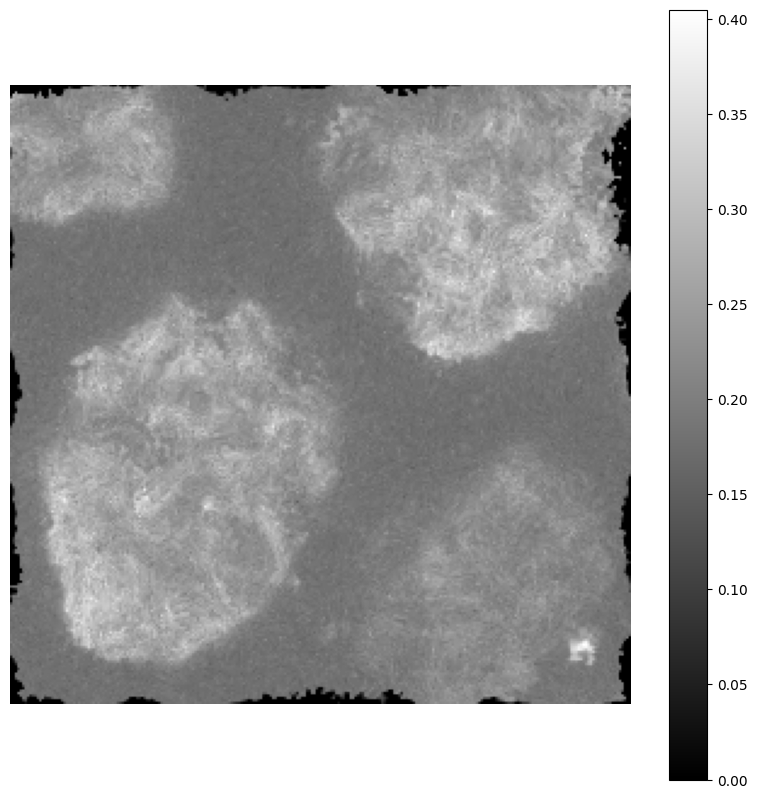

Shape of mid_frame: (256, 256)
Min value: 0.0, Max value: 0.4048123359680176
Unique values: [0.0000000e+00 3.1715674e-05 4.7982245e-05 ... 3.8805121e-01 4.0127581e-01
 4.0481234e-01]
tensor([[[[[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           ...,
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.]],

          [[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 0., 0.,  ..., 0., 0., 0.],
           [1., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [1., 0., 0.,  ..., 0., 0., 0.],
           [1., 0., 0.,  ..., 0., 0., 0.],
           [1., 0., 0.,  ..., 0., 0., 0.]],

          [[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 0., 0.,  ..., 0., 0., 0.],
           [1., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [1., 0., 0.,  ..., 0., 0., 0.],
           [1., 0., 0.,  ..., 0., 0., 0.],
           [1., 0., 0.,  ..., 0., 

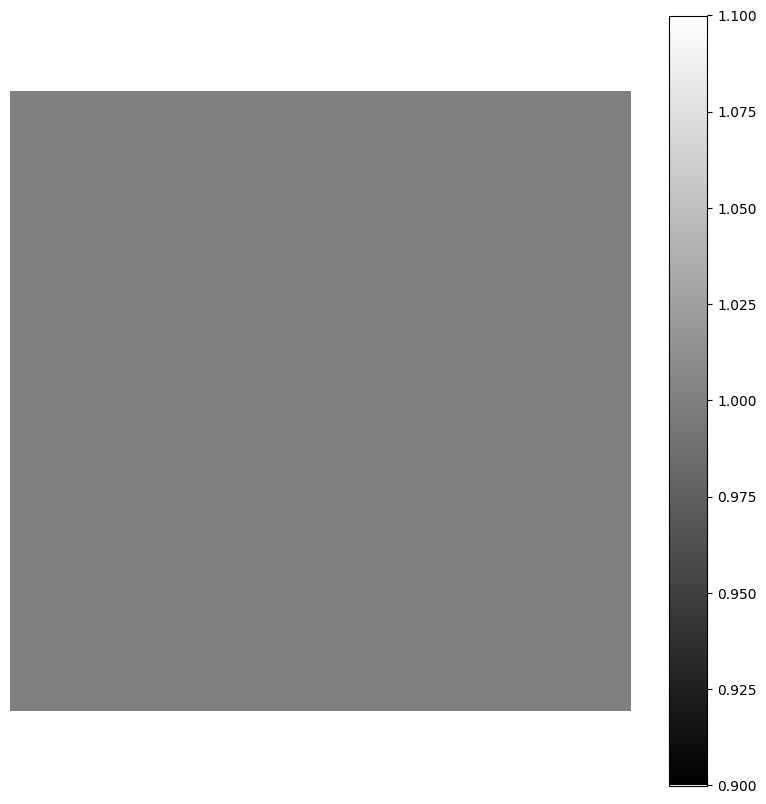

Shape of mid_frame: (256, 256)
Min value: 1.0, Max value: 1.0
Unique values: [1.]


In [7]:
# 对原图进行变形
deformed, flow = model.deform(sample_input)
visualize_mid_frame(deformed)
grid = model.create_grid_image()
print(grid)
visualize_mid_frame(grid)

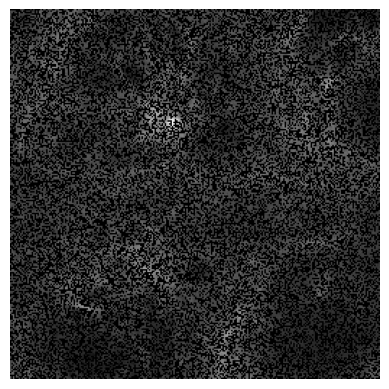

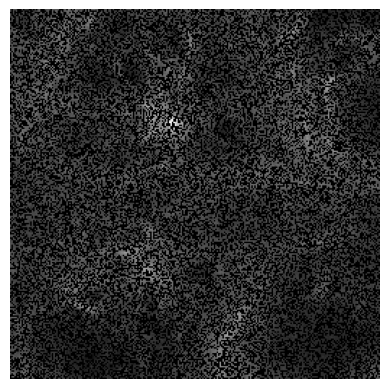

In [22]:
masked_a = model.mask(sample_input)
masked_b = model.mask(sample_input)
visualize_mid_frame(masked_a)
visualize_mid_frame(masked_b)

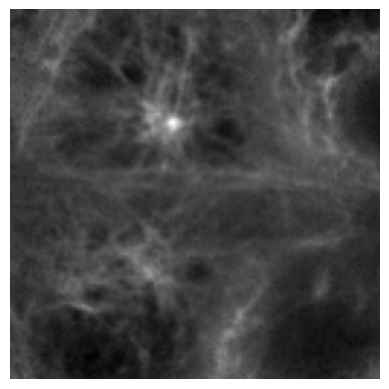

In [23]:
downsampled = model.downsample(sample_input)
visualize_mid_frame(downsampled)

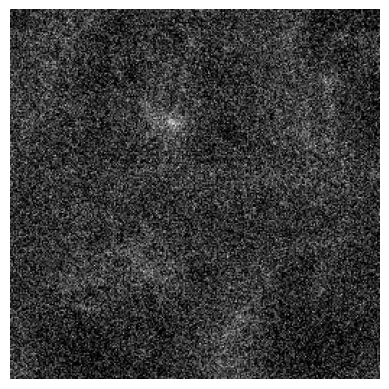

In [24]:
noise = model.noise(sample_input)
visualize_mid_frame(noise)

sample_input.shape: torch.Size([1, 1, 64, 224, 224]), device: cuda:0
Logits structure:
raw
  <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
reg
  deformed
    <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
  flow
    <class 'numpy.ndarray'>, Shape: (1, 3, 64, 224, 224)
  deformed_grid
    <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
  inverted_flow
    <class 'numpy.ndarray'>, Shape: (1, 3, 64, 224, 224)
  restored_grid
    <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
  registered
    <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
fus
  masked_A
    <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
  masked_B
    <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
  fused
    <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
SR
  downsampled
    <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
  super_resolution
    <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
IR
  noisy
    <class 'numpy.ndarray'>, Shape: (1, 1, 64, 224, 224)
  rest

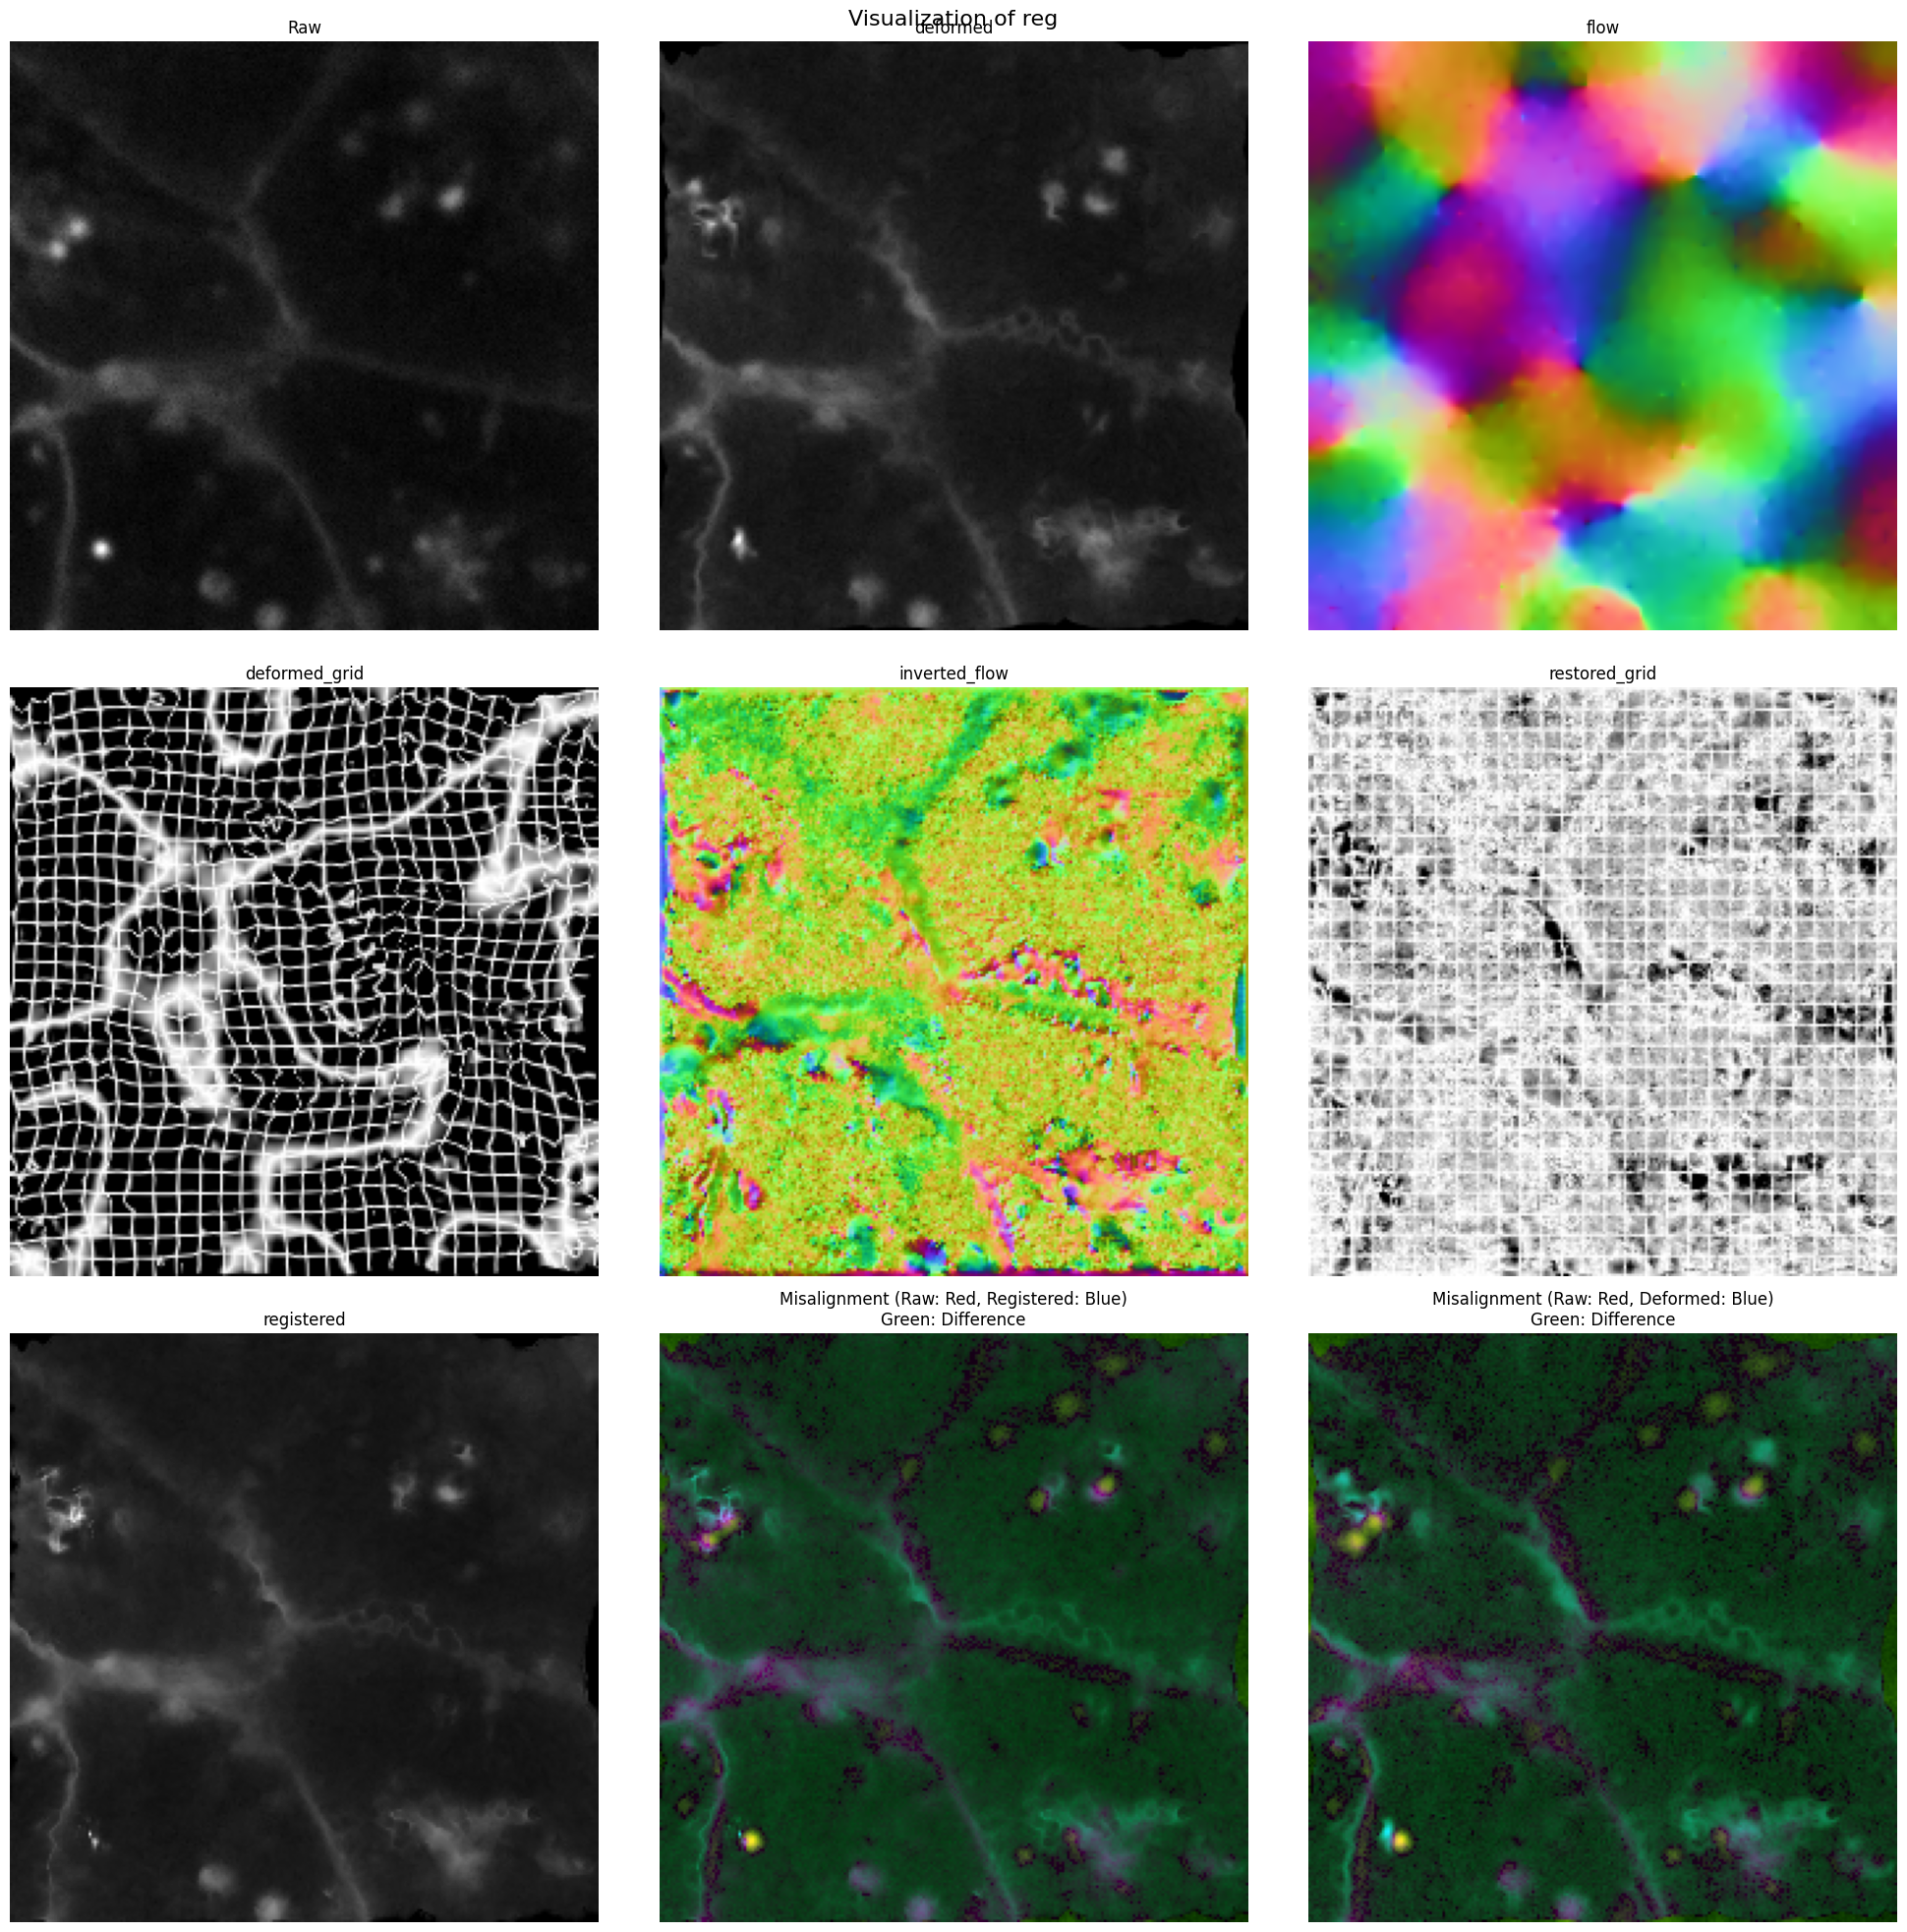

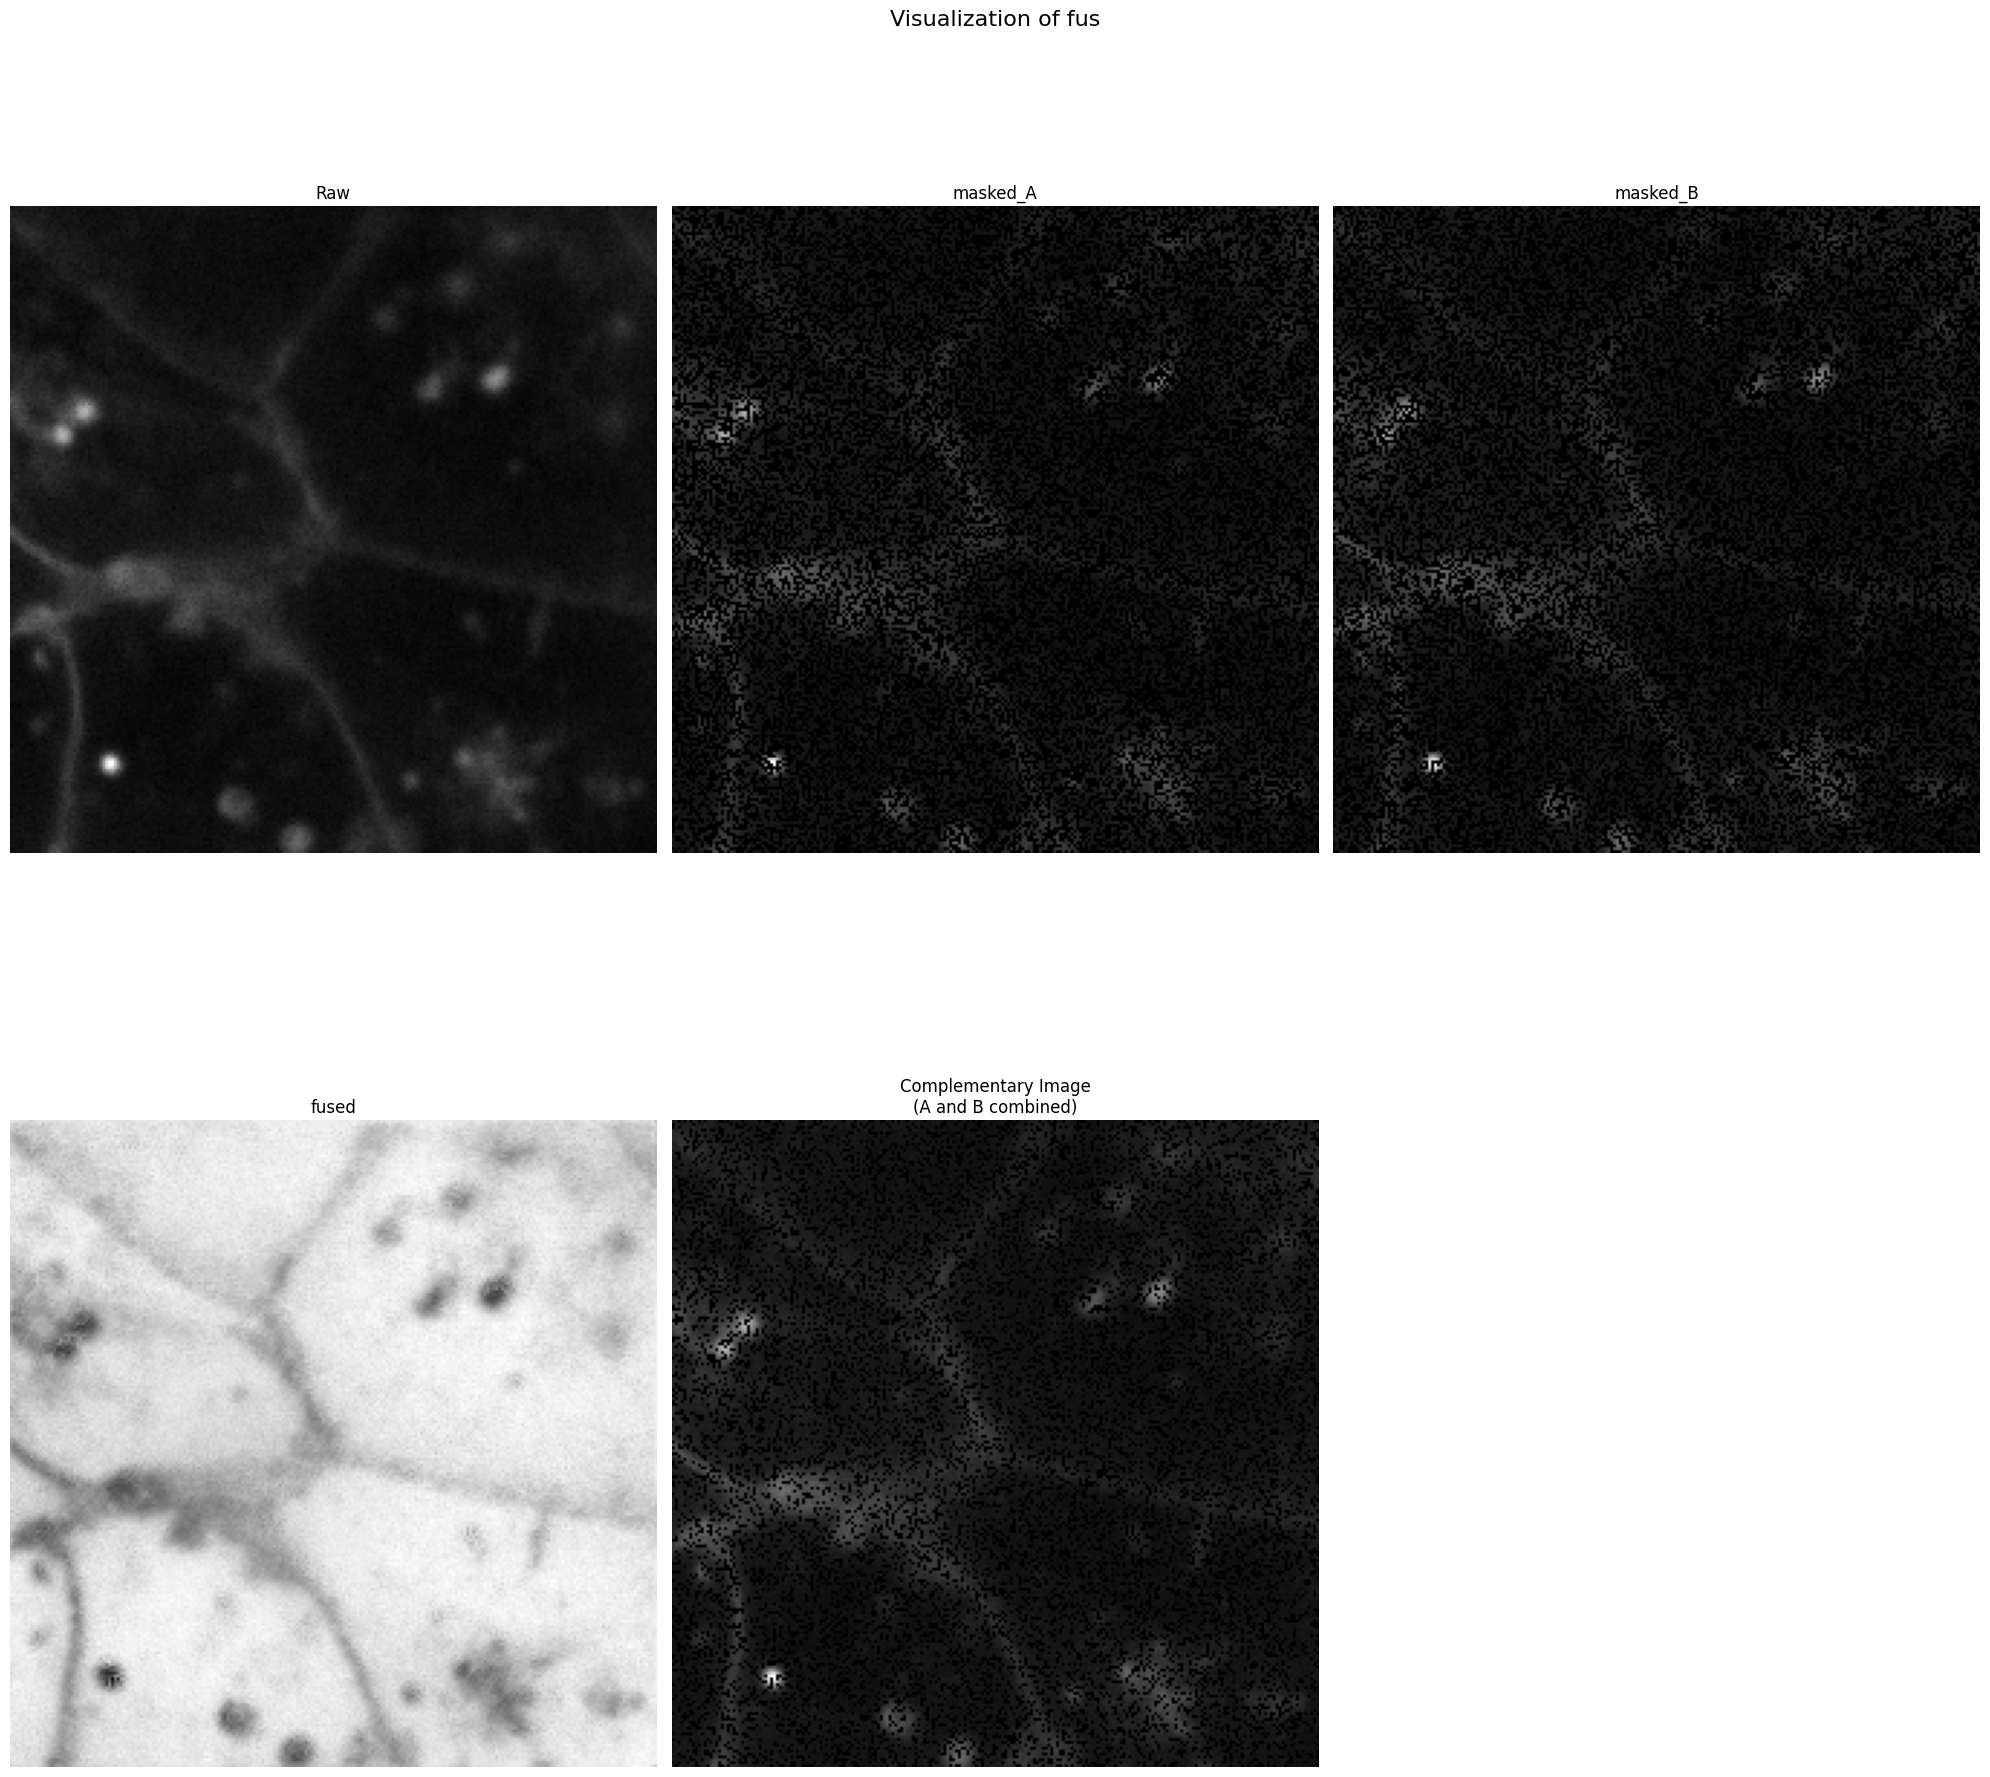

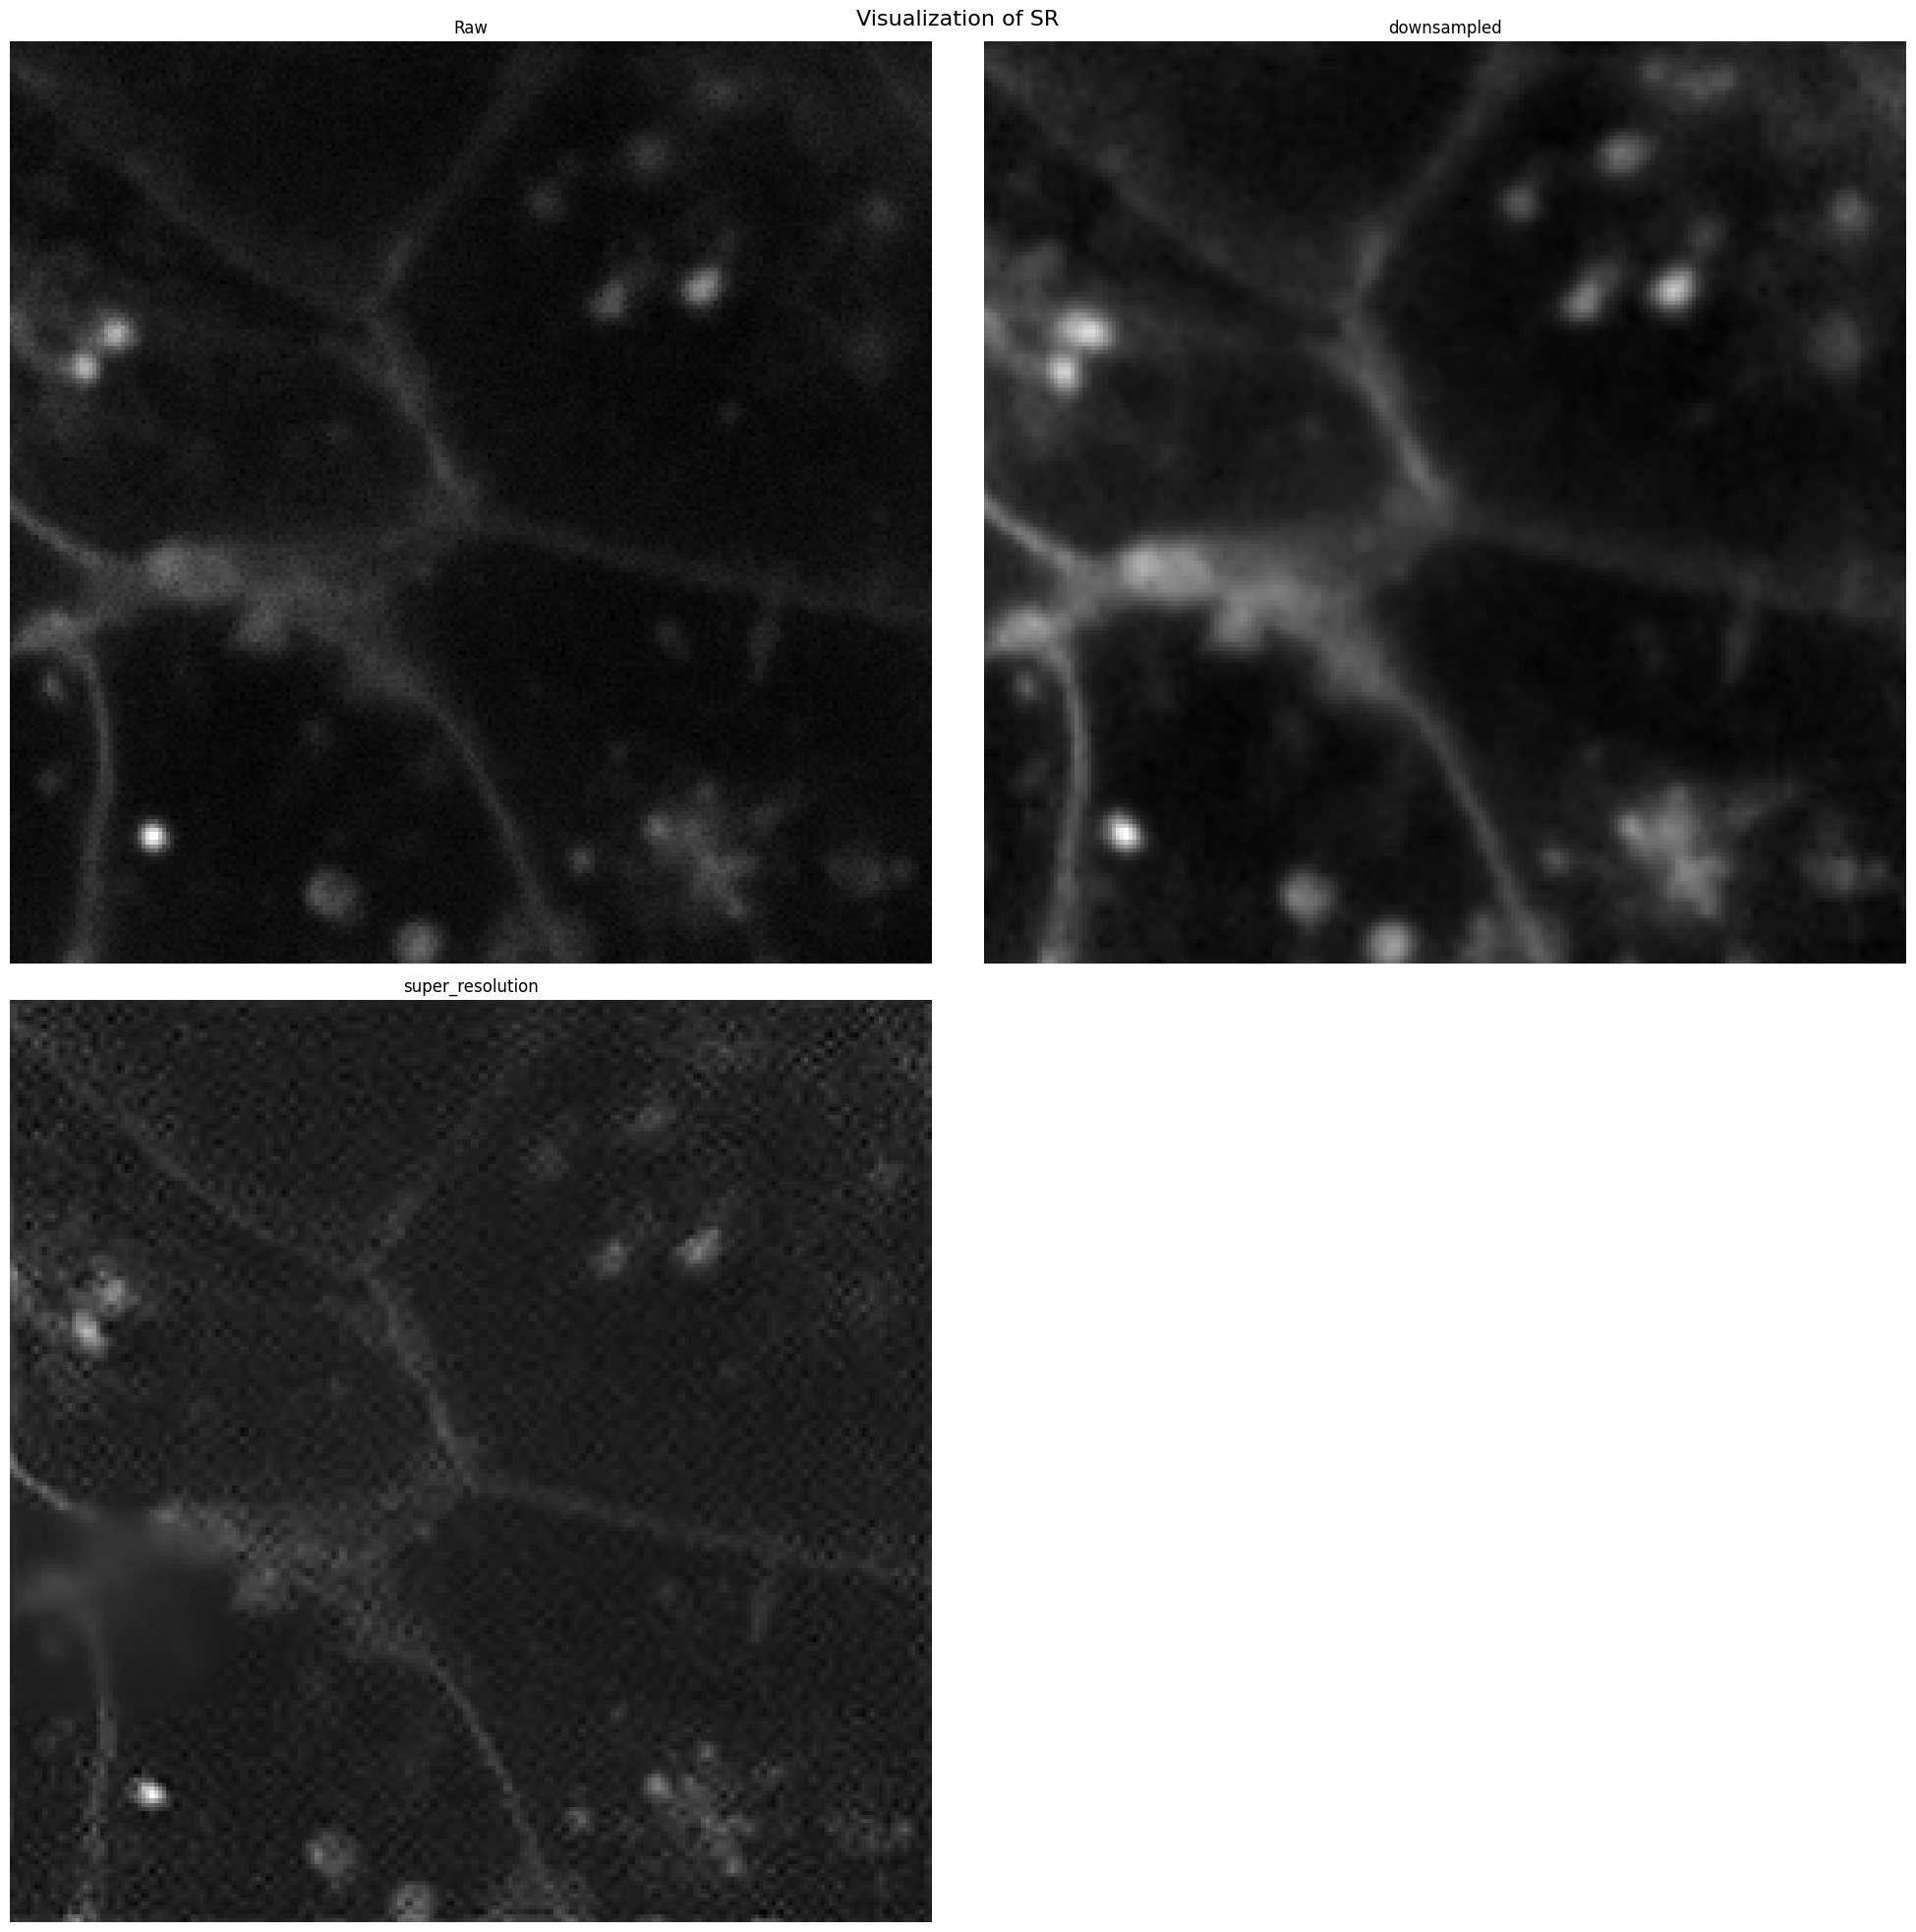

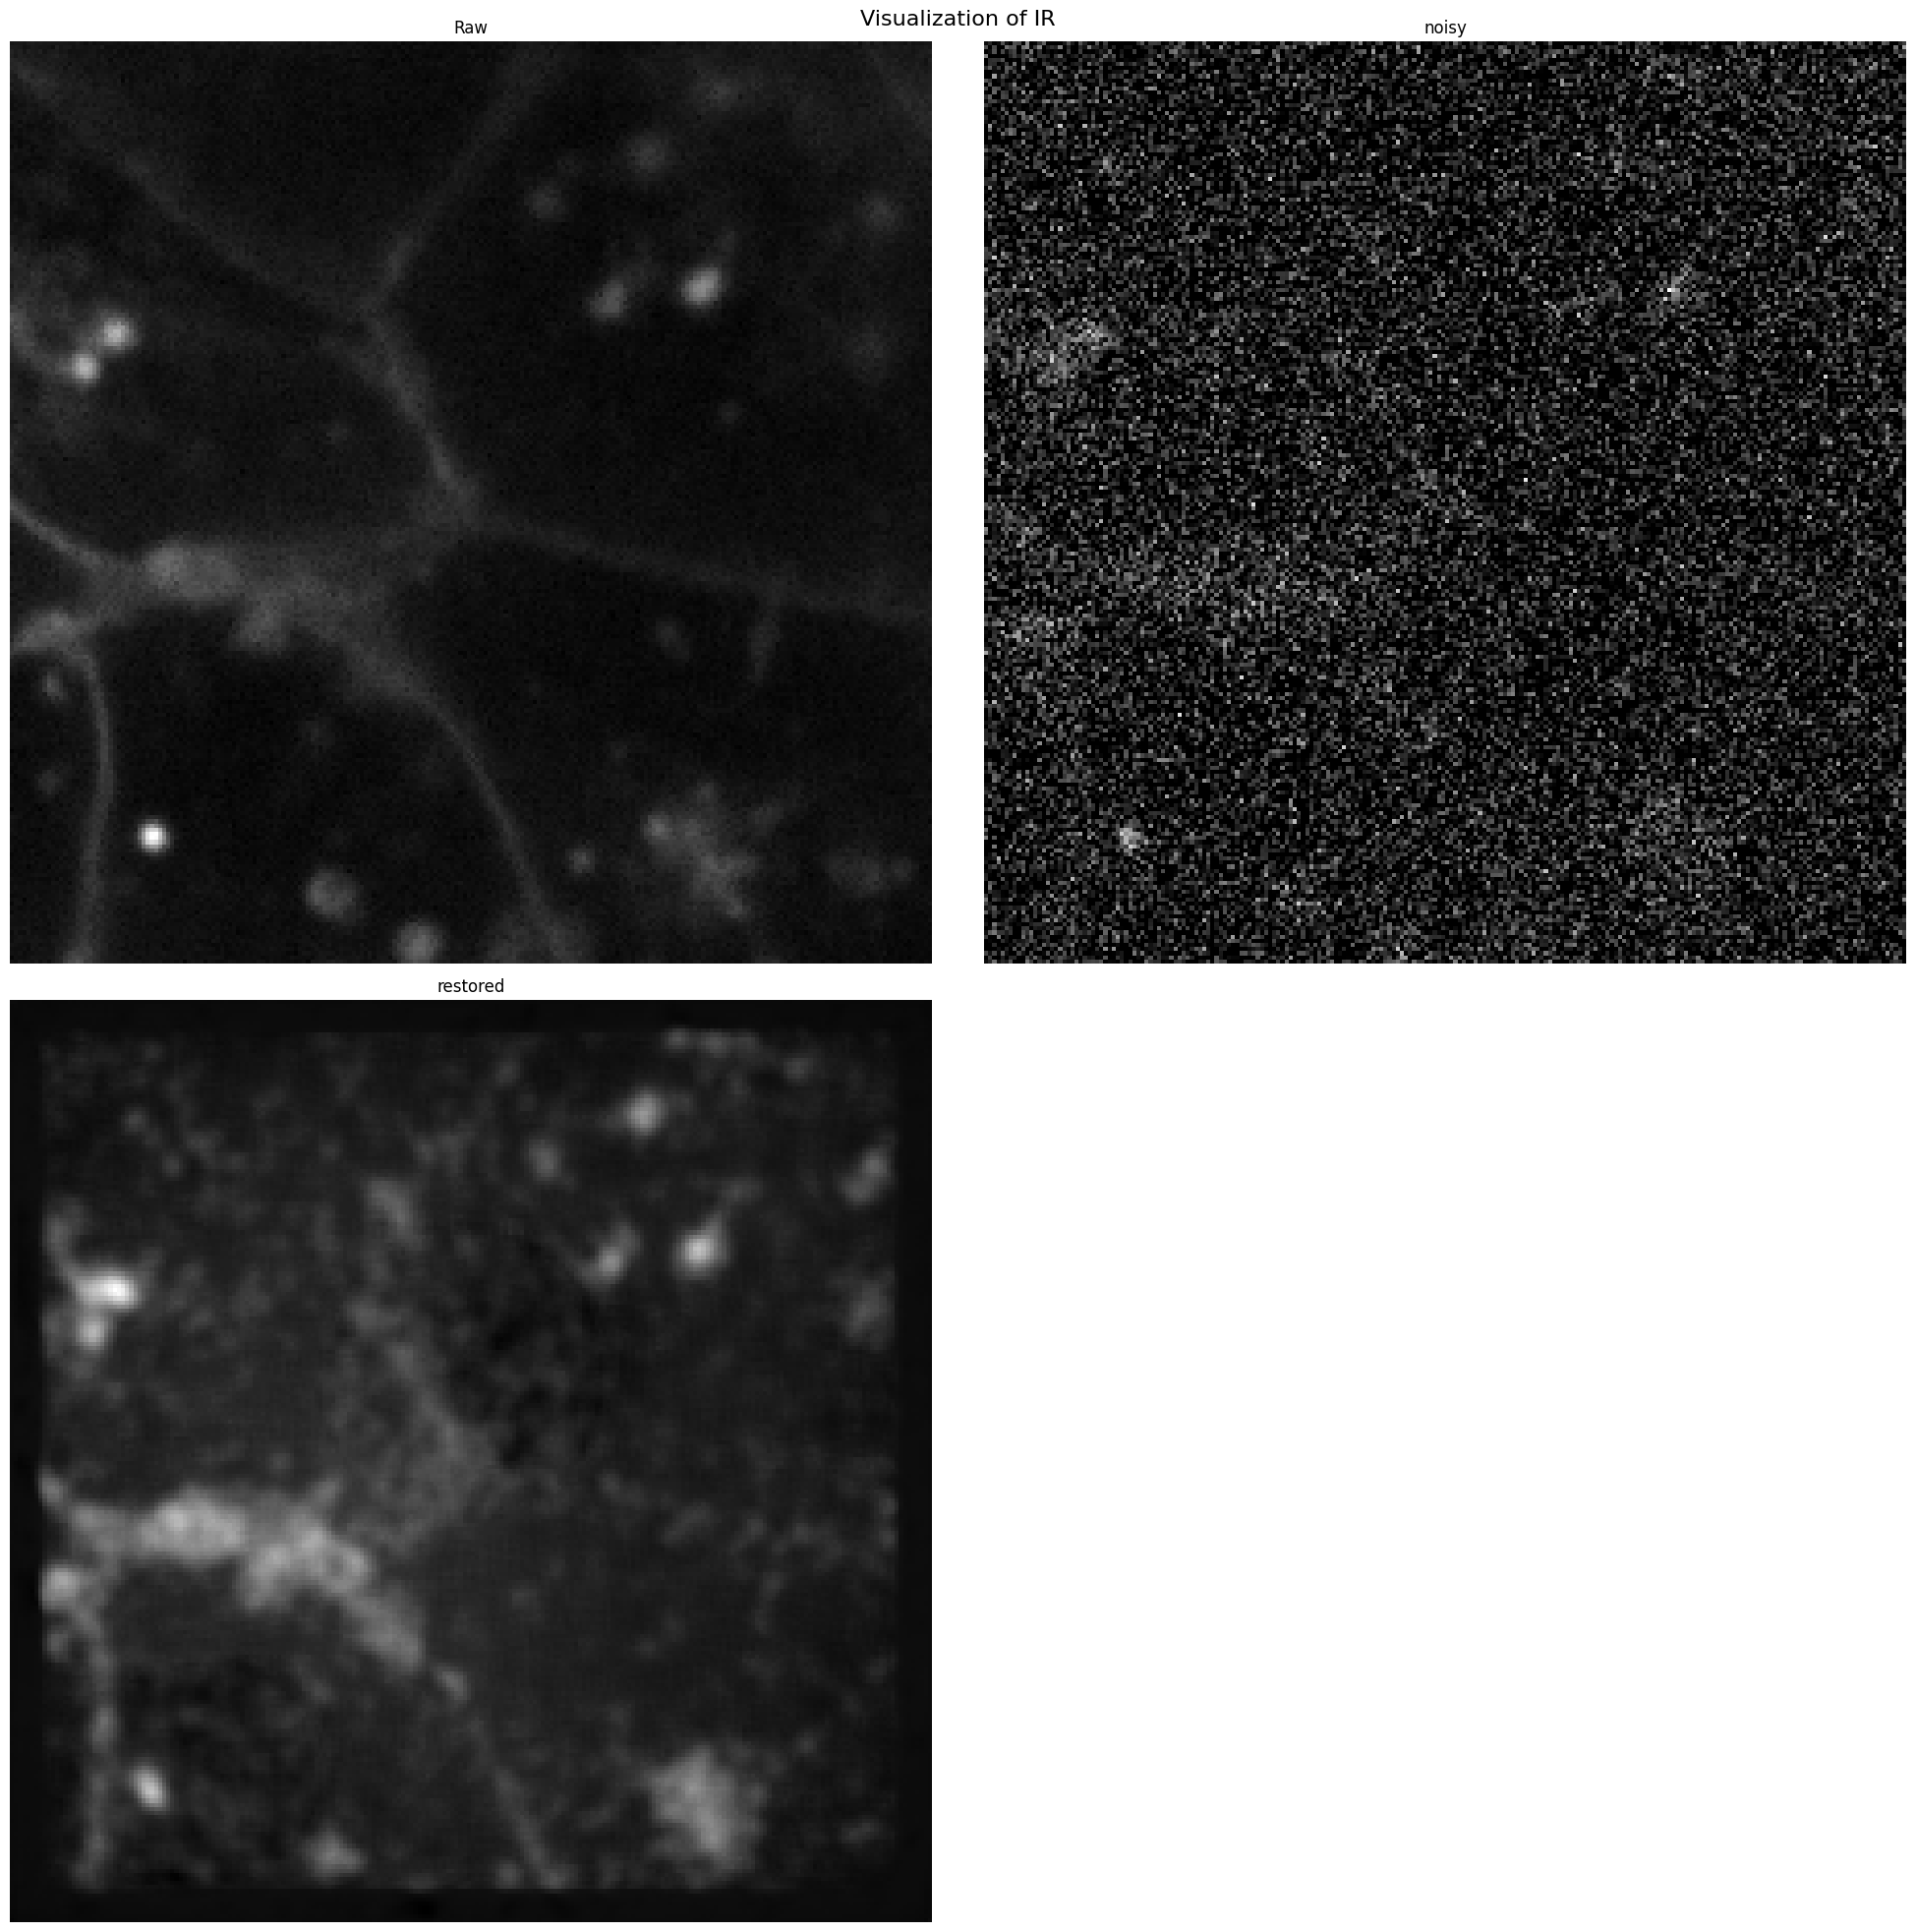

In [4]:
with torch.no_grad():
    model.eval()    
    sample_input = sample_input
    logits, aux_loss = model(sample_input)

visualize_logits(logits)